# GIM Trends: State-wise Funding and Area Allocation Analysis

## **Problem Statements**

### **Problem Statement 1: State-wise Allocation Consistency**
Identify if any states consistently receive disproportionately higher funding allocations over time.

### **Problem Statement 2: Allocation vs. Area Correlation**
Analyze the relationship between total funding allocation and the total physical area of a state to uncover patterns and correlations.

### **Problem Statement 3: Annual Trends in Funding and Coverage**
Examine the yearly trends in overall funding and physical area coverage to understand changes and developments over the years.

In [2]:
# imported the necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# **Data Cleaning Process**

**Imported the Data :**

In [3]:
df = pd.read_csv("/content/raw_data.csv")
df

,States,Released Amount (In Rs. Crore) 2015-16,Physical Area (ha) 2015-16,Released Amount (In Rs. Crore) 2016-17,Physical Area (ha) 2016-17,Released Amount (In Rs. Crore) 2017-18,Physical Area (ha) 2017-18,Released Amount (In Rs. Crore) 2018-19,Physical Area (ha) 2018-19,Released Amount (In Rs. Crore) 2019-20,Physical Area (ha) 2019-20,Released Amount (In Rs. Crore) 2020-21,Physical Area (ha) 2020-21,Released Amount (In Rs. Crore) 2021-22,Physical Area (ha) 2021-22,Released Amount (In Rs. Crore) 2022-23,Physical Area (ha) 2022-23,Total Released Amount (In Rs. Crore),Total Physical Area (ha)
0,Andhra Pradesh,NaN,NaN,1.05530,534,0.446,Committed Liability,2.6662,2203,NaN,NaN,NaN,NaN,2.023596,1656,NaN,NaN,6.191096,4393.000
1,Arunachal Pradesh,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.432000,10777,21.28000,Committed Liability,34.712000,10777.000
2,Chhattisgarh,23.3860,19128.00,20.23000,Committed Liability,10.953,Committed Liability,5.3607,Committed Liability,5.036080,Committed Liability,1.660924,1063,6.120000,4419,NaN,NaN,72.746704,24610.000
3,Haryana,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.550000,6174,NaN,NaN,9.550000,6174.000
4,Himachal Pradesh,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.085000,5480,NaN,NaN,NaN,NaN,17.085000,5480.000
5,Jammu & Kashmir,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25.727000,5680,NaN,NaN,6.49000,1891,32.217000,7571.000
6,Karnataka,1.0553,760.00,0.86853,Committed Liability,0.85734,Committed Liability,1.6234,600,2.209930,Committed Liability,2.351396,560,4.446490,515,2.92844,360,16.340826,2795.000
7,Kerala,9.1482,4978.00,NaN,NaN,Committed Liability,7319.766,NaN,NaN,16.318130,Committed Liability,NaN,NaN,NaN,NaN,NaN,NaN,25.466330,12297.766
8,Madhya Pradesh,NaN,NaN,NaN,NaN,NaN,NaN,24.1590,11914,30.652980,11444,NaN,NaN,18.285244,7259,17.93000,5000,91.027224,35617.000
9,Maharashtra,NaN,NaN,NaN,NaN,NaN,NaN,10.3020,6766,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.302000,6766.000


In [4]:
df.info() # Description of the data frame

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 19 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   States                                  18 non-null     object 
 1   Released Amount (In Rs. Crore) 2015-16  8 non-null      float64
 2   Physical Area (ha) 2015-16              8 non-null      float64
 3   Released Amount (In Rs. Crore) 2016-17  7 non-null      float64
 4   Physical Area (ha) 2016-17              7 non-null      object 
 5   Released Amount (In Rs. Crore) 2017-18  9 non-null      object 
 6   Physical Area (ha) 2017-18              9 non-null      object 
 7   Released Amount (In Rs. Crore) 2018-19  10 non-null     float64
 8   Physical Area (ha) 2018-19              10 non-null     object 
 9   Released Amount (In Rs. Crore) 2019-20  11 non-null     float64
 10  Physical Area (ha) 2019-20              11 non-null     object 


**Providing Index Values For Better Visualization :**

In [5]:
df.index = df.index + 1 #Updated the index values from 1
df

,States,Released Amount (In Rs. Crore) 2015-16,Physical Area (ha) 2015-16,Released Amount (In Rs. Crore) 2016-17,Physical Area (ha) 2016-17,Released Amount (In Rs. Crore) 2017-18,Physical Area (ha) 2017-18,Released Amount (In Rs. Crore) 2018-19,Physical Area (ha) 2018-19,Released Amount (In Rs. Crore) 2019-20,Physical Area (ha) 2019-20,Released Amount (In Rs. Crore) 2020-21,Physical Area (ha) 2020-21,Released Amount (In Rs. Crore) 2021-22,Physical Area (ha) 2021-22,Released Amount (In Rs. Crore) 2022-23,Physical Area (ha) 2022-23,Total Released Amount (In Rs. Crore),Total Physical Area (ha)
1,Andhra Pradesh,NaN,NaN,1.05530,534,0.446,Committed Liability,2.6662,2203,NaN,NaN,NaN,NaN,2.023596,1656,NaN,NaN,6.191096,4393.000
2,Arunachal Pradesh,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.432000,10777,21.28000,Committed Liability,34.712000,10777.000
3,Chhattisgarh,23.3860,19128.00,20.23000,Committed Liability,10.953,Committed Liability,5.3607,Committed Liability,5.036080,Committed Liability,1.660924,1063,6.120000,4419,NaN,NaN,72.746704,24610.000
4,Haryana,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.550000,6174,NaN,NaN,9.550000,6174.000
5,Himachal Pradesh,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.085000,5480,NaN,NaN,NaN,NaN,17.085000,5480.000
6,Jammu & Kashmir,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25.727000,5680,NaN,NaN,6.49000,1891,32.217000,7571.000
7,Karnataka,1.0553,760.00,0.86853,Committed Liability,0.85734,Committed Liability,1.6234,600,2.209930,Committed Liability,2.351396,560,4.446490,515,2.92844,360,16.340826,2795.000
8,Kerala,9.1482,4978.00,NaN,NaN,Committed Liability,7319.766,NaN,NaN,16.318130,Committed Liability,NaN,NaN,NaN,NaN,NaN,NaN,25.466330,12297.766
9,Madhya Pradesh,NaN,NaN,NaN,NaN,NaN,NaN,24.1590,11914,30.652980,11444,NaN,NaN,18.285244,7259,17.93000,5000,91.027224,35617.000
10,Maharashtra,NaN,NaN,NaN,NaN,NaN,NaN,10.3020,6766,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.302000,6766.000


**Changes the Datetype to Numeric :**

In [6]:
numeric_cols = df.columns.drop('States') #Converted the Datatypes except States Column
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')
df

,States,Released Amount (In Rs. Crore) 2015-16,Physical Area (ha) 2015-16,Released Amount (In Rs. Crore) 2016-17,Physical Area (ha) 2016-17,Released Amount (In Rs. Crore) 2017-18,Physical Area (ha) 2017-18,Released Amount (In Rs. Crore) 2018-19,Physical Area (ha) 2018-19,Released Amount (In Rs. Crore) 2019-20,Physical Area (ha) 2019-20,Released Amount (In Rs. Crore) 2020-21,Physical Area (ha) 2020-21,Released Amount (In Rs. Crore) 2021-22,Physical Area (ha) 2021-22,Released Amount (In Rs. Crore) 2022-23,Physical Area (ha) 2022-23,Total Released Amount (In Rs. Crore),Total Physical Area (ha)
1,Andhra Pradesh,NaN,NaN,1.05530,534.00,0.44600,NaN,2.6662,2203.0,NaN,NaN,NaN,NaN,2.023596,1656.0,NaN,NaN,6.191096,4393.000
2,Arunachal Pradesh,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.432000,10777.0,21.28000,NaN,34.712000,10777.000
3,Chhattisgarh,23.3860,19128.00,20.23000,NaN,10.95300,NaN,5.3607,NaN,5.036080,NaN,1.660924,1063.0,6.120000,4419.0,NaN,NaN,72.746704,24610.000
4,Haryana,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.550000,6174.0,NaN,NaN,9.550000,6174.000
5,Himachal Pradesh,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.085000,5480.0,NaN,NaN,NaN,NaN,17.085000,5480.000
6,Jammu & Kashmir,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25.727000,5680.0,NaN,NaN,6.49000,1891.0,32.217000,7571.000
7,Karnataka,1.0553,760.00,0.86853,NaN,0.85734,NaN,1.6234,600.0,2.209930,NaN,2.351396,560.0,4.446490,515.0,2.92844,360.0,16.340826,2795.000
8,Kerala,9.1482,4978.00,NaN,NaN,NaN,7319.766,NaN,NaN,16.318130,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25.466330,12297.766
9,Madhya Pradesh,NaN,NaN,NaN,NaN,NaN,NaN,24.1590,11914.0,30.652980,11444.0,NaN,NaN,18.285244,7259.0,17.93000,5000.0,91.027224,35617.000
10,Maharashtra,NaN,NaN,NaN,NaN,NaN,NaN,10.3020,6766.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.302000,6766.000


In [7]:
df.head() # Fetching first 5 rows

,States,Released Amount (In Rs. Crore) 2015-16,Physical Area (ha) 2015-16,Released Amount (In Rs. Crore) 2016-17,Physical Area (ha) 2016-17,Released Amount (In Rs. Crore) 2017-18,Physical Area (ha) 2017-18,Released Amount (In Rs. Crore) 2018-19,Physical Area (ha) 2018-19,Released Amount (In Rs. Crore) 2019-20,Physical Area (ha) 2019-20,Released Amount (In Rs. Crore) 2020-21,Physical Area (ha) 2020-21,Released Amount (In Rs. Crore) 2021-22,Physical Area (ha) 2021-22,Released Amount (In Rs. Crore) 2022-23,Physical Area (ha) 2022-23,Total Released Amount (In Rs. Crore),Total Physical Area (ha)
1,Andhra Pradesh,NaN,NaN,1.0553,534.0,0.446,NaN,2.6662,2203.0,NaN,NaN,NaN,NaN,2.023596,1656.0,NaN,NaN,6.191096,4393.0
2,Arunachal Pradesh,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.432000,10777.0,21.28,NaN,34.712000,10777.0
3,Chhattisgarh,23.386,19128.0,20.2300,NaN,10.953,NaN,5.3607,NaN,5.03608,NaN,1.660924,1063.0,6.120000,4419.0,NaN,NaN,72.746704,24610.0
4,Haryana,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.550000,6174.0,NaN,NaN,9.550000,6174.0
5,Himachal Pradesh,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.085000,5480.0,NaN,NaN,NaN,NaN,17.085000,5480.0


In [8]:
df.tail() #Fetching last 4 rows

,States,Released Amount (In Rs. Crore) 2015-16,Physical Area (ha) 2015-16,Released Amount (In Rs. Crore) 2016-17,Physical Area (ha) 2016-17,Released Amount (In Rs. Crore) 2017-18,Physical Area (ha) 2017-18,Released Amount (In Rs. Crore) 2018-19,Physical Area (ha) 2018-19,Released Amount (In Rs. Crore) 2019-20,Physical Area (ha) 2019-20,Released Amount (In Rs. Crore) 2020-21,Physical Area (ha) 2020-21,Released Amount (In Rs. Crore) 2021-22,Physical Area (ha) 2021-22,Released Amount (In Rs. Crore) 2022-23,Physical Area (ha) 2022-23,Total Released Amount (In Rs. Crore),Total Physical Area (ha)
14,Punjab,6.1153,3000.00,NaN,NaN,6.21730,1304.000,NaN,NaN,3.185700,NaN,NaN,NaN,3.31738,1500.0,2.73929,1650.0,21.574970,7454.000
15,Sikkim,NaN,NaN,NaN,NaN,NaN,NaN,3.3236,1509.2,3.124200,NaN,2.192870,NaN,7.77000,2474.0,6.57250,2998.0,22.983170,6981.200
16,Uttarakhand,20.2090,7483.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27.891000,3562.0,33.99300,2295.0,28.39900,3557.0,110.492000,16897.000
17,West Bengal,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.426488,18666.0,NaN,NaN,NaN,NaN,0.76000,NaN,10.186488,18666.000
18,Total,70.0914,46324.56,41.24983,20197.84,46.29504,8644.606,79.4303,29957.2,106.013998,37560.0,112.653701,24467.0,156.46109,41233.0,137.29483,19486.0,749.490189,227870.206


In [9]:
print(df.isnull().sum(),"\n") #Checking for null values

print("Total Null values : ", df.isnull().sum().sum())

States                                     0
Released Amount (In Rs. Crore) 2015-16    10
Physical Area (ha) 2015-16                10
Released Amount (In Rs. Crore) 2016-17    11
Physical Area (ha) 2016-17                14
Released Amount (In Rs. Crore) 2017-18    10
Physical Area (ha) 2017-18                14
Released Amount (In Rs. Crore) 2018-19     8
Physical Area (ha) 2018-19                11
Released Amount (In Rs. Crore) 2019-20     7
Physical Area (ha) 2019-20                14
Released Amount (In Rs. Crore) 2020-21     8
Physical Area (ha) 2020-21                11
Released Amount (In Rs. Crore) 2021-22     5
Physical Area (ha) 2021-22                 6
Released Amount (In Rs. Crore) 2022-23     6
Physical Area (ha) 2022-23                 8
Total Released Amount (In Rs. Crore)       0
Total Physical Area (ha)                   0
dtype: int64 

Total Null values :  153


### Handling Missing Values

Many of the 'Released Amount' and 'Physical Area' columns have `NaN` values. For this dataset, a `NaN` likely indicates that no amount was released or no physical area was recorded for that state in that specific year. Therefore, we will fill these `NaN` values with `0` to ensure they are treated as zero contributions rather than missing data, which is appropriate for calculating totals and trends.

In [10]:
columns_to_fill_zero = [col for col in df.columns if 'Released Amount (In Rs. Crore)' in col or 'Physical Area (ha)' in col]
columns_to_fill_zero = [col for col in columns_to_fill_zero if 'Total' not in col]

# Fill NaN values in these specific columns with 0
df[columns_to_fill_zero] = df[columns_to_fill_zero].fillna(0)

df.isnull().sum()

,0
States,0
Released Amount (In Rs. Crore) 2015-16,0
Physical Area (ha) 2015-16,0
Released Amount (In Rs. Crore) 2016-17,0
Physical Area (ha) 2016-17,0
Released Amount (In Rs. Crore) 2017-18,0
Physical Area (ha) 2017-18,0
Released Amount (In Rs. Crore) 2018-19,0
Physical Area (ha) 2018-19,0
Released Amount (In Rs. Crore) 2019-20,0


In [11]:
df.to_csv('cleaned_gim_data.csv', index=False)
print("Cleaned data saved to 'cleaned_gim_data.csv'")

Cleaned data saved to 'cleaned_gim_data.csv'


##**Problem Statement 1**

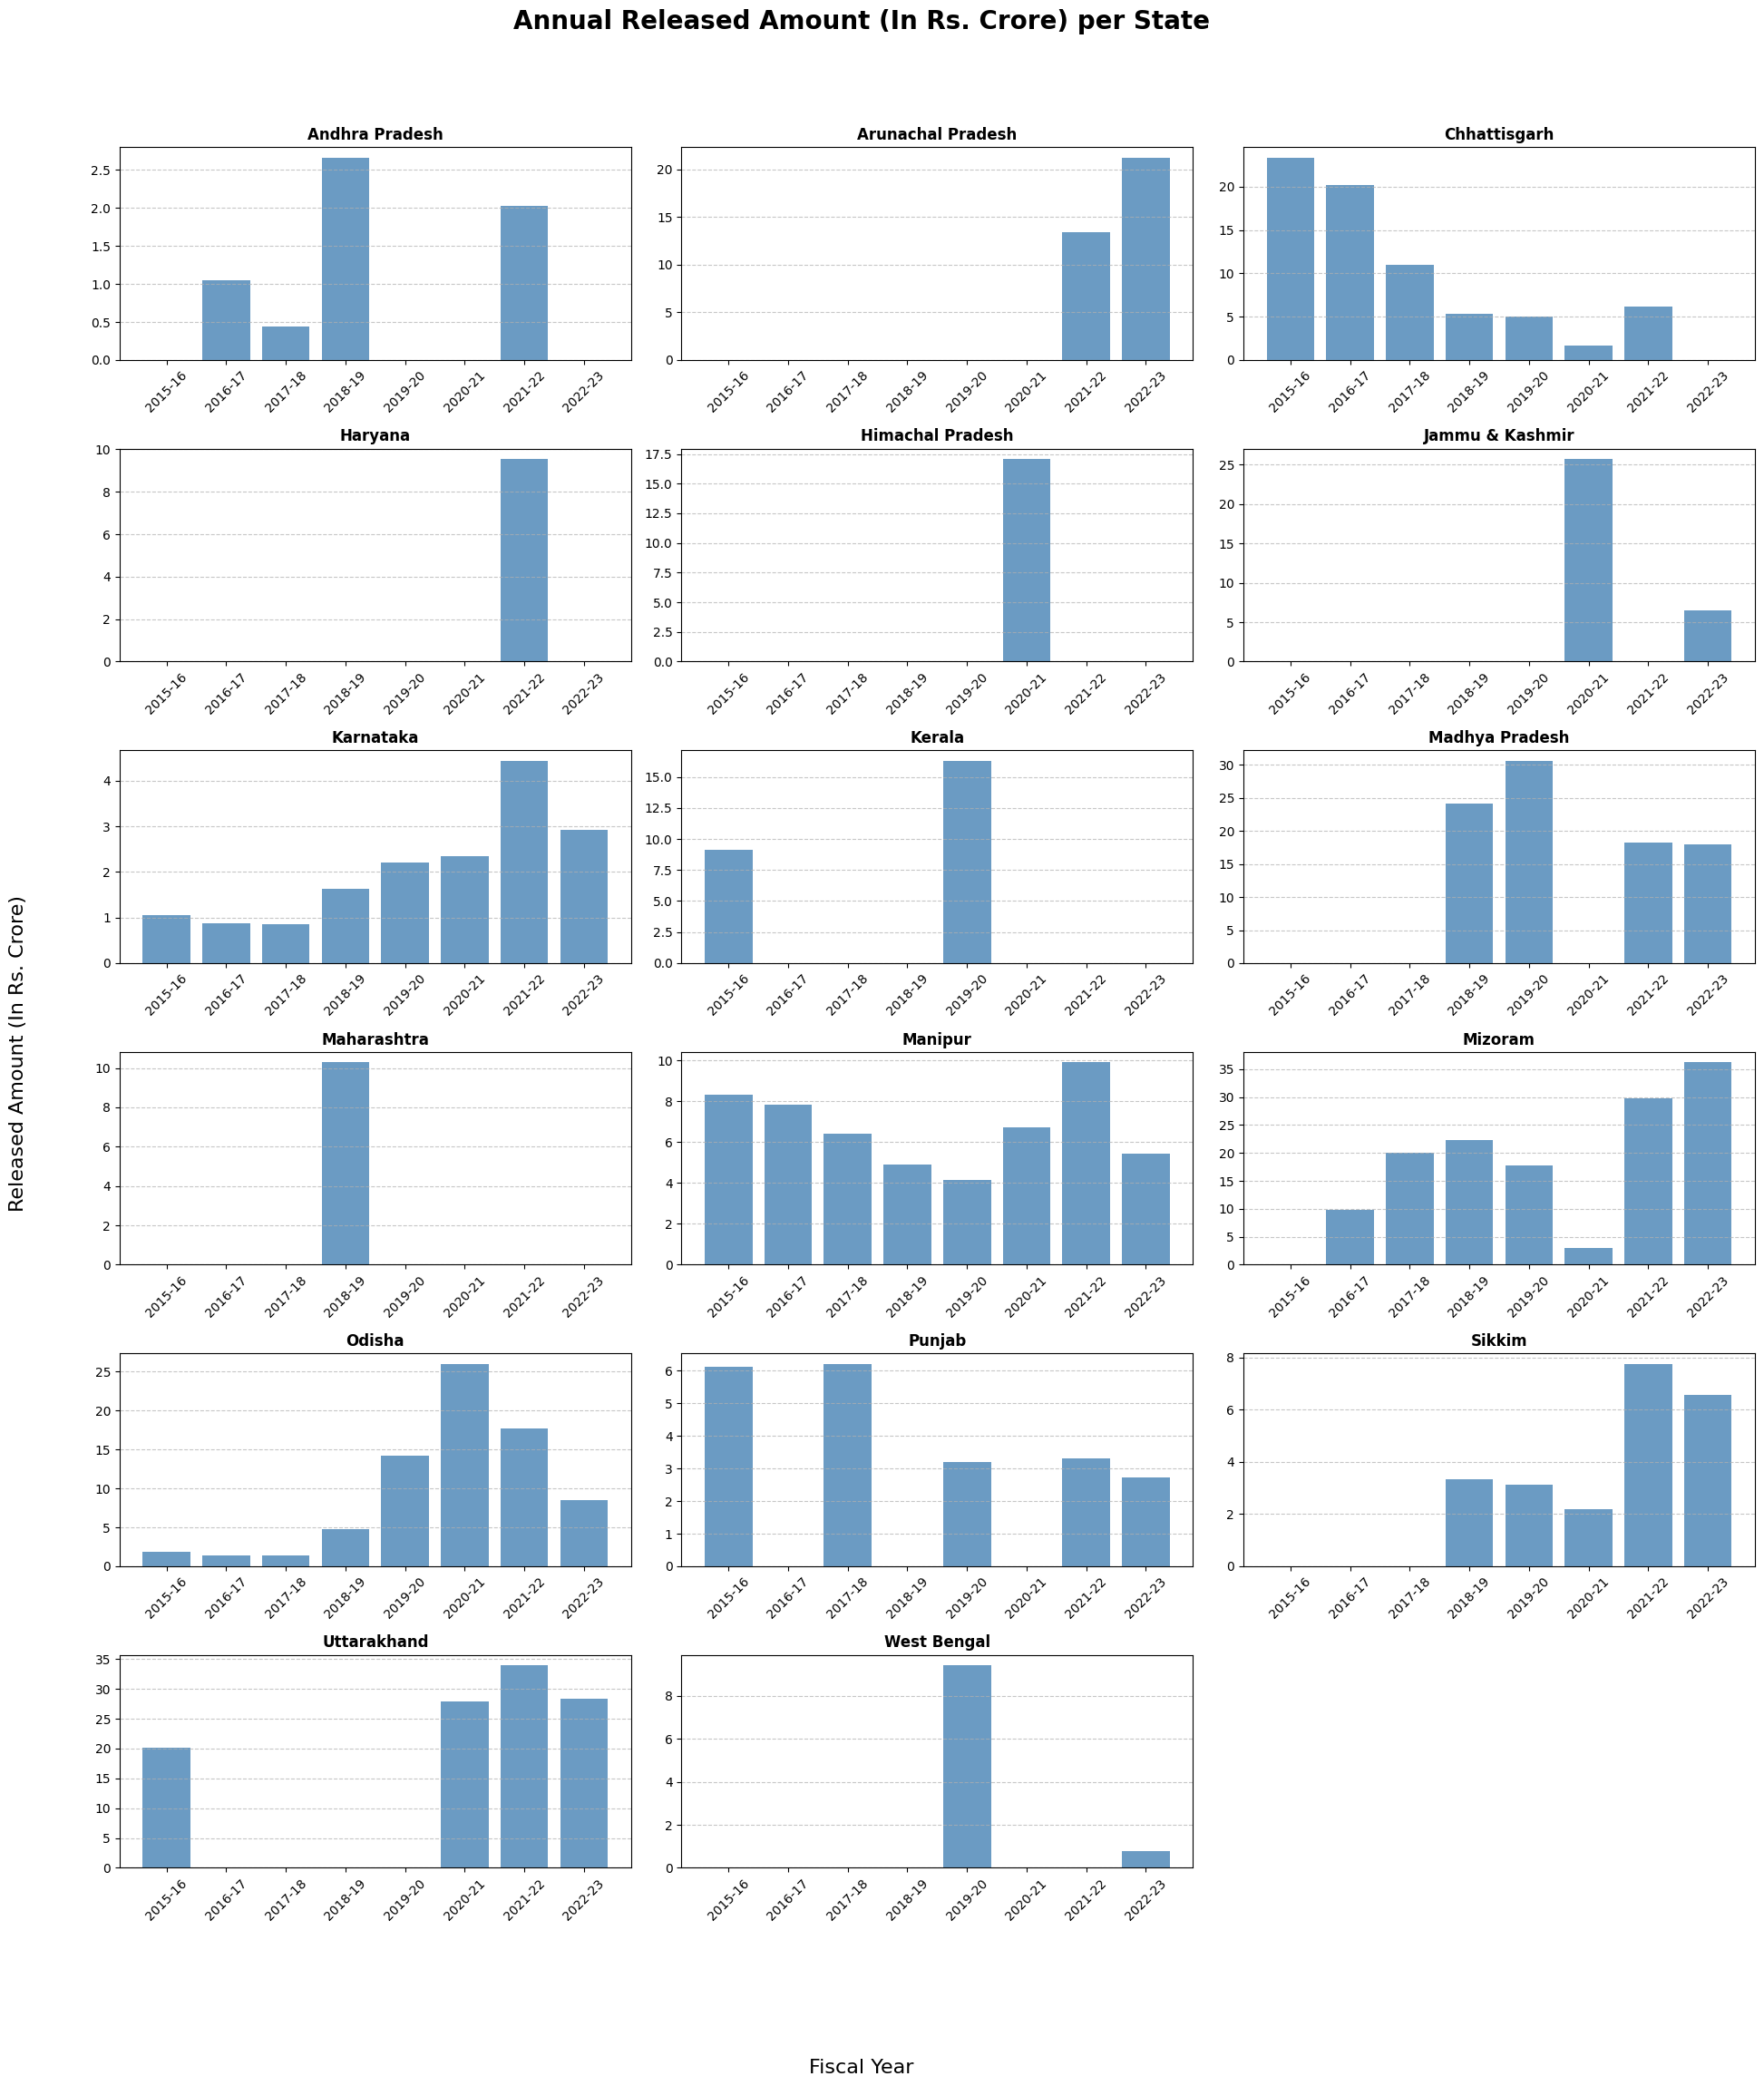

In [15]:
import math

states_to_plot = [
    'Andhra Pradesh', 'Arunachal Pradesh', 'Chhattisgarh', 'Haryana', 'Himachal Pradesh',
    'Jammu & Kashmir', 'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Manipur',
    'Mizoram', 'Odisha', 'Punjab', 'Sikkim', 'Uttarakhand', 'West Bengal']

years = ['2015-16', '2016-17', '2017-18', '2018-19', '2019-20', '2020-21', '2021-22', '2022-23']

num_states = len(states_to_plot)
ncols = 3
nrows = math.ceil(num_states / ncols) # Calculate rows needed dynamically

# Set up subplots with dynamic rows and fixed columns
fig, axes = plt.subplots(nrows, ncols, figsize=(20, nrows * 4), sharey=False)
axes = axes.flatten()  # Flatten the grid into a 1D array for easy access

# Add a super title for the entire figure
fig.suptitle('Annual Released Amount (In Rs. Crore) per State', fontsize=20, weight='bold')

# Add shared x and y axis labels for the entire figure
fig.supxlabel('Fiscal Year', fontsize=16, y=0.03)
fig.supylabel('Released Amount (In Rs. Crore)', fontsize=16, x=0.03)

# Loop through each state and create a bar plot
for i, state in enumerate(states_to_plot):
    # Filter data for the current state
    state_data = df[df['States'] == state]

    # Extract released amounts for the given years
    released_amounts = [
        state_data[f'Released Amount (In Rs. Crore) {year}'].iloc[0] if not state_data.empty else 0
        for year in years
    ]

    # Plot the data in the corresponding subplot
    axes[i].bar(years, released_amounts, color='steelblue', alpha=0.8) # Changed color, added alpha
    axes[i].set_title(state, fontsize=12, weight='semibold')  # Increased title font size, added weight
    axes[i].tick_params(axis='x', rotation=45, labelsize=10) # Increased x-axis label font size
    axes[i].tick_params(axis='y', labelsize=10) # Added y-axis label font size
    axes[i].grid(axis='y', linestyle='--', alpha=0.7) # Added grid for better readability

# Remove extra axes if the number of states is less than the total grid cells
for j in range(num_states, len(axes)):
    fig.delaxes(axes[j])  # Delete unused subplots

# Adjust layout to prevent overlap and make it visually appealing
plt.tight_layout(rect=[0.05, 0.08, 1, 0.95]) # Adjust rect to make space for suptitle and supx/y labels
plt.show()

### Insight: State-wise Funding Allocation Trends

This visualization clearly shows the annual released amounts for each state over the fiscal years 2015-16 to 2022-23. Upon review, several observations can be made:

*   **Varying Allocation Levels**: There is significant variability in the funding received by different states. Some states, such as Manipur, appear to receive consistently higher allocations, while others show more sporadic or lower funding.
*   **Inconsistent Funding for Many States**: A notable pattern is the inconsistency in funding for many states. Several states have years with zero or very low allocations, indicating that funding is not uniformly distributed or consistently provided across all states every year.
*   **Potential for Disproportionate Allocation**: The visualization suggests that certain states might be receiving disproportionately higher funding compared to others, which aligns with Problem Statement 1. Further analysis would be needed to determine if this is based on need, project proposals, or other factors.
*   **Yearly Fluctuations**: Even for states that receive funding, the amounts often fluctuate significantly from year to year, rather than showing a steady increase or decrease. This could reflect project-based funding, budget cycles, or specific state-level initiatives.

##**Problem Statement 2**

In [13]:
df.rename(columns={'Total Physical Area (ha) ': 'Total Physical Area'}, inplace=True)

# Verify the change
print(df.columns)

Index(['States', 'Released Amount (In Rs. Crore) 2015-16',
       'Physical Area (ha) 2015-16', 'Released Amount (In Rs. Crore) 2016-17',
       'Physical Area (ha) 2016-17', 'Released Amount (In Rs. Crore) 2017-18',
       'Physical Area (ha) 2017-18', 'Released Amount (In Rs. Crore) 2018-19',
       'Physical Area (ha) 2018-19', 'Released Amount (In Rs. Crore) 2019-20',
       'Physical Area (ha) 2019-20', 'Released Amount (In Rs. Crore) 2020-21',
       'Physical Area (ha) 2020-21', 'Released Amount (In Rs. Crore) 2021-22',
       'Physical Area (ha) 2021-22', 'Released Amount (In Rs. Crore) 2022-23',
       'Physical Area (ha) 2022-23', 'Total Released Amount (In Rs. Crore) ',
       'Total Physical Area'],
      dtype='object')


In [14]:
plt.figure(figsize=(15, 10))  # Adjust figure size for better visualization

# Create a line plot
sns.lineplot(x='States', y='Total Released Amount (In Rs. Crore) ', data=data,color="purple" , marker="o")

# Rotate x-axis labels for readability
plt.xticks(rotation=45, ha='right')  # Rotate labels and align them to the right


# Add title and labels
plt.title('Total Released Amount (In Rs. Crore) by State')
plt.xlabel('States')
plt.ylabel('Total Released Amount (In Rs. Crore)')

# Display the plot
plt.tight_layout()  # Adjust layout to prevent labels from overlapping
plt.show()

NameError: name 'data' is not defined

<Figure size 1500x1000 with 0 Axes>

In [ ]:
plt.figure(figsize=(15, 10))  # Adjust figure size for better visualization

# Create a line plot
sns.lineplot(x='States', y='Total Physical Area', data=data , color="blue",marker="o")

# Rotate x-axis labels for readability
plt.xticks(rotation=45, ha='right')  # Rotate labels and align them to the right


# Add title and labels
plt.title('Total Physical Area by State')
plt.xlabel('States')
plt.ylabel('Total Physical Area')

# Display the plot
plt.tight_layout()  # Adjust layout to prevent labels from overlapping
plt.show()

# ***Conclusion: We can see that there is an uneven pattern in the total allocation with respect to the total area of the state***

#**Problem Statement 3**

In [ ]:
# Extract funding and coverage columns
funding_columns = [col for col in df.columns if 'Released Amount (In Rs. Crore)' in col and 'Total' not in col]
coverage_columns = [col for col in df.columns if 'Physical Area (ha)' in col and 'Total' not in col]

# Extract years by taking only the starting part of the year range (e.g., '2015' from '2015-16')
years = [col.split()[-1].split('-')[0] for col in funding_columns]

# Calculate total funding and coverage for each year
total_funding = df[funding_columns].sum().values
total_coverage = df[coverage_columns].sum().values

# Create a DataFrame for trends
trends = pd.DataFrame({
    'Year': years,
    'Total Funding (Rs. Crore)': total_funding,
    'Total Coverage (ha)': total_coverage
})

# Convert Year to an integer for proper sorting
trends['Year'] = trends['Year'].astype(int)

# Plot the trends
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot Funding as a bar chart
ax1.bar(trends['Year'], trends['Total Funding (Rs. Crore)'], color='skyblue', label='Funding')
ax1.set_xlabel('Year')
ax1.set_ylabel('Total Funding (Rs. Crore)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Plot Coverage as a line chart on a secondary axis
ax2 = ax1.twinx()
ax2.plot(trends['Year'], trends['Total Coverage (ha)'], color='green', marker='o', label='Coverage')
ax2.set_ylabel('Total Area Allocated (ha)', color='green')
ax2.tick_params(axis='y', labelcolor='green')

# Add a title and adjust layout
plt.title('Annual Trends in Overall Funding and Coverage')
fig.tight_layout()
plt.show()

In [ ]:
y = [16.340826,6.1910963,17.085,9.55,10.302,22.98317,21.57497,32.217,34.712,25.46633,110.492,10.186488,53.75384,139.079311,75.78223,72.746704,91.027224]
x = [2759,4393,5480,6174,6766,6981.2,7454,7571,10777,12297.766,16897,18666,19976,20643,20772.24,24610,35617]
state = ['Karnataka','Andhra Pradesh','Himachal Pradesh','Haryana','Maharashtra','Sikkim','Punjab','Jammu & Kashmir','Arunachal Pradesh','Kerala','Uttarakhand','West Bengal','Manipur','Mizoram','Odisha','Chhattisgarh','Madhya Pradesh']

plt.plot(x, y, color='blue', linestyle='dashed', linewidth = 1, marker='o', markerfacecolor='blue', markersize=4)

plt.ylabel('released amount (cr)')

plt.xlabel('physical area (ha)')
for i in range(len(state)):
    plt.text(x[i],y[i],state[i],fontsize=7)

plt.title('Annual trends')

plt.show()

# ***Conclusion: This graph illustrates the number of physical areas allocated and the budget provided over the past eight years, offering insights into the trends and distribution patterns during this period.***